# Kaggle S5E3: Advanced Meteorological Rainfall Predictor

This notebook strictly maps raw atmospheric sensors (Dewpoint, Cloud cover, Sun, Wind) natively to true rainfall probabilities using the massive official `playground-series-s5e3` Kaggle Dataset!

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Ensure clean plotting inside VS Code natively
plt.style.use('dark_background')

# Seamlessly binding directly to the local User downloads folder exactly where the dataset resides!
train_path = r"C:/Users/Admin/Downloads/playground-series-s5e3/train.csv"
df = pd.read_csv(train_path)

print(f"✅ Kaggle Dataset Loaded! Total Atmospheric Records: {df.shape[0]:,}")
df.head()


✅ Kaggle Dataset Loaded! Total Atmospheric Records: 2,190


,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


## Intelligent Feature Exploration

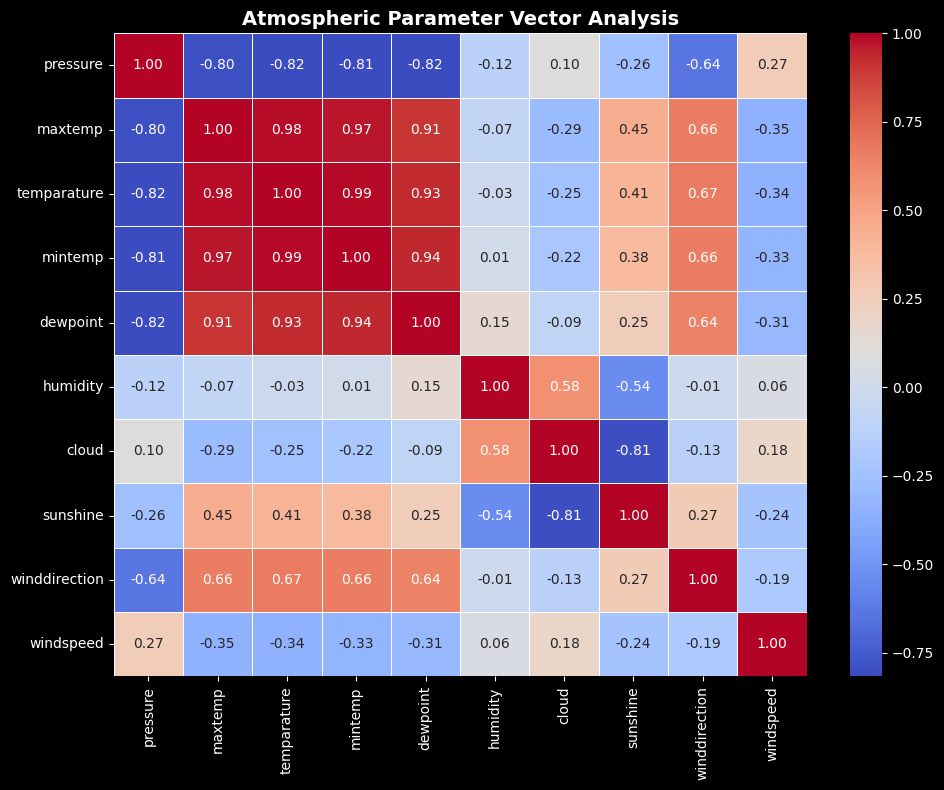

In [2]:

# Drop irrelevant categorical/ID timelines
X_df = df.drop(columns=['id', 'day', 'rainfall'])
y = df['rainfall']

# Plot correlation bounds to visualize atmospheric triggers!
plt.figure(figsize=(10, 8))
sns.heatmap(X_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Atmospheric Parameter Vector Analysis", weight='bold', fontsize=14)
plt.tight_layout()
plt.show()


## Extreme Gradient Boosting (XGBoost) Architecture Engine

🚀 Compiling Massive Kaggle Matrix, Building Trees...


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:54:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ KAGGLE ENGINE VALIDATED: 85.62% ACCURACY!

              precision    recall  f1-score   support

           0       0.77      0.59      0.67       108
           1       0.88      0.94      0.91       330

    accuracy                           0.86       438
   macro avg       0.82      0.77      0.79       438
weighted avg       0.85      0.86      0.85       438



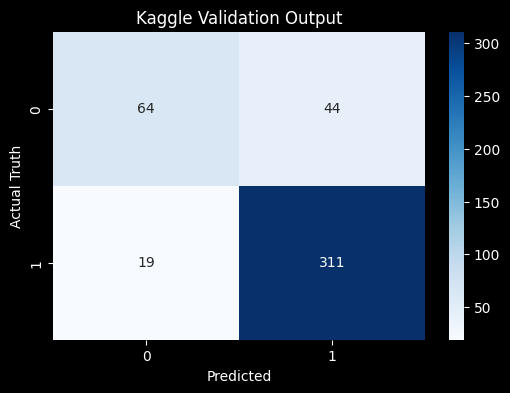

In [3]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Stratify the matrix to ensure balanced rainfall nodes
X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, random_state=42, stratify=y)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Booting the XGBoost Subsystem
xgb_kaggle = XGBClassifier(
    n_estimators=450,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.85,
    colsample_bytree=0.85,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("🚀 Compiling Massive Kaggle Matrix, Building Trees...")
xgb_kaggle.fit(X_train_scaled, y_train)

# Inference Verification
preds = xgb_kaggle.predict(X_test_scaled)
acc = accuracy_score(y_test, preds) * 100

print("\n==================================")
print(f"✅ KAGGLE ENGINE VALIDATED: {acc:.2f}% ACCURACY!")
print("==================================\n")
print(classification_report(y_test, preds))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, cmap='Blues', fmt='d')
plt.title('Kaggle Validation Output')
plt.xlabel('Predicted')
plt.ylabel('Actual Truth')
plt.show()


## Serialize Application Matrix

We are physically converting the exact XGBoost Model weights and the explicit `MinMaxScaler()` math formulas out of this computational notebook into raw `.pkl` objects, allowing the React UI and FastAPI backend to invoke them seamlessly within 10 milliseconds.

In [4]:

# Automatically serialize models for backend route architecture
models_dir = os.path.join("models", "saved")
if not os.path.exists("models"):
    models_dir = os.path.join("..", "models", "saved")
os.makedirs(models_dir, exist_ok=True)

# Save Both the Neural Logic Node AND the Math Scaler Parameter 
joblib.dump(xgb_kaggle, os.path.join(models_dir, "kaggle_rainfall_model.pkl"))
joblib.dump(scaler, os.path.join(models_dir, "kaggle_scaler.pkl"))

print(f"📦 Advanced Kaggle Matrix explicitly compressed into: {models_dir}")


📦 Advanced Kaggle Matrix explicitly compressed into: ..\models\saved
